# WORLD TOURISM ANALYTICS

## Data Warehouse y Análisis del Turismo Mundial

### Análisis Exploratorio de Datos (EDA)

**Álvaro Muzás Antuña**

Septiembre 2026

# 1. INTRODUCCIÓN

## 1.1. Descripción del proyecto

Este notebook forma parte del proyecto **World Tourism Analytics**, desarrollado con el objetivo de analizar el turismo internacional y estudiar su relación con diferentes factores económicos, sociales y patrimoniales.

Para ello, se integran diferentes fuentes de datos relacionadas con las llegadas de turistas internacionales, el PIB per cápita, la felicidad, la paz, la población y el patrimonio mundial de la UNESCO.

El análisis se desarrolla a partir de los datos previamente auditados, limpiados y estructurados durante las fases de preparación y construcción del Data Warehouse.

## 1.2. Pregunta de negocio

**¿Qué países están experimentando el mayor crecimiento turístico y qué factores explican ese crecimiento?**

## 1.3. Objetivo del análisis

El objetivo de este notebook es realizar un **Análisis Exploratorio de Datos (EDA)** que permita conocer la estructura, calidad y comportamiento de las principales variables del proyecto.

A través de diferentes análisis estadísticos y visualizaciones se identificarán patrones generales, distribuciones, tendencias temporales y posibles relaciones entre las variables antes de desarrollar los análisis de correlación y las visualizaciones finales del proyecto.

## 2.1. Fuentes de datos

El proyecto **World Tourism Analytics** se ha construido a partir de la integración de diferentes fuentes de datos relacionadas con el turismo internacional y con distintos factores económicos, sociales y patrimoniales.

Los principales datasets utilizados son:

- **International Tourist**: llegadas de turistas internacionales por país y año.
- **GDP per Capita**: PIB per cápita por país y año.
- **Population**: población por país y año.
- **World Happiness**: indicadores relacionados con la felicidad y el bienestar.
- **Global Peace Index**: indicadores relacionados con el nivel de paz de los países.
- **UNESCO World Heritage**: información sobre los sitios declarados Patrimonio Mundial.

Los datasets fueron previamente auditados, limpiados y preparados mediante **Excel y Power Query** antes de su integración en el Data Warehouse.

## 2.2. Variables principales

Para el análisis exploratorio se trabajará principalmente con las siguientes variables:

| Variable | Descripción |
|---|---|
| `country` | Nombre del país |
| `country_code` | Código ISO del país |
| `year` | Año del registro |
| `population` | Población del país |
| `gdp_per_capita` | PIB per cápita |
| `tourist_arrivals` | Llegadas de turistas internacionales |
| `unesco_sites` | Número de sitios UNESCO |
| `happiness_score` | Puntuación de felicidad |
| `peace_score` | Puntuación del Global Peace Index |

Estas variables permiten analizar conjuntamente el comportamiento turístico y su relación con diferentes características económicas, sociales y patrimoniales.

## 2.3. Periodo y cobertura de los datos

Los datasets utilizados en el análisis presentan diferentes periodos de cobertura temporal en función de la fuente y de la disponibilidad de información.

El dataset Tourism contiene información desde 1995 hasta 2024, mientras que los datasets GDP per Capita y Population presentan series históricas desde 1960. World Happiness, Global Peace Index y UNESCO presentan periodos de cobertura diferentes.

Por este motivo, el análisis descriptivo y exploratorio utiliza el periodo disponible en cada dataset. Para los análisis que requieren combinar diferentes fuentes, se utiliza 2024 como año de referencia común.

# 3. CARGA Y EXPLORACIÓN INICIAL

## 3.1. Importación de librerías

Para comenzar el análisis exploratorio se importan las principales librerías de Python que se utilizarán para la manipulación, análisis y visualización de los datos.

Las principales herramientas utilizadas serán:

- **Pandas**: manipulación y análisis de datos.
- **NumPy**: operaciones numéricas.
- **Matplotlib**: creación de visualizaciones.

In [2]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 3.2. Carga del dataset

Para realizar el análisis exploratorio se utilizará el conjunto de datos integrado en el Data Warehouse, correspondiente a la información disponible para los países y años analizados.

En primer lugar, se cargará el archivo de datos en un DataFrame de Pandas para poder realizar la exploración y posterior visualización mediante Python.

In [3]:
# ============================================================
# CARGA DE LOS DATASETS
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving gdp_per_capita_clean.csv to gdp_per_capita_clean.csv
Saving global_peace_index_clean.csv to global_peace_index_clean.csv
Saving population_clean.csv to population_clean.csv
Saving tourism_clean.csv to tourism_clean.csv
Saving unesco_clean.csv to unesco_clean.csv
Saving world_happiness_clean.csv to world_happiness_clean.csv


## 3.3. Lectura de los datasets

Una vez cargados los archivos en Google Colab, se importan mediante Pandas para poder trabajar con ellos en el análisis exploratorio.

Cada dataset se mantiene inicialmente en un DataFrame independiente, ya que contiene información correspondiente a una fuente y temática diferente.

In [4]:
# ============================================================
# LECTURA DE LOS DATASETS
# ============================================================

gdp = pd.read_csv("gdp_per_capita_clean.csv", sep=";")
peace = pd.read_csv("global_peace_index_clean.csv", sep=";")
population = pd.read_csv("population_clean.csv", sep=";")
tourism = pd.read_csv("tourism_clean.csv", sep=";")
unesco = pd.read_csv("unesco_clean.csv", sep=";")
happiness = pd.read_csv("world_happiness_clean.csv", sep=";")

print("Los 6 datasets se han cargado correctamente.")

Los 6 datasets se han cargado correctamente.


## 3.4. Estructura de los datasets

Una vez cargados los archivos, se comprueba el número de registros y variables disponibles en cada dataset.

Esta primera revisión permite verificar que los archivos se han importado correctamente y conocer la estructura inicial de los datos antes de comenzar el análisis exploratorio.

In [5]:
# ============================================================
# ESTRUCTURA DE LOS DATASETS
# ============================================================

datasets = {
    "GDP per Capita": gdp,
    "Global Peace Index": peace,
    "Population": population,
    "Tourism": tourism,
    "UNESCO": unesco,
    "World Happiness": happiness
}

for nombre, df in datasets.items():
    print(f"{nombre}: {df.shape[0]} filas y {df.shape[1]} columnas")

GDP per Capita: 265 filas y 68 columnas
Global Peace Index: 163 filas y 40 columnas
Population: 265 filas y 68 columnas
Tourism: 5241 filas y 5 columnas
UNESCO: 1248 filas y 13 columnas
World Happiness: 2116 filas y 13 columnas


## 3.5. Primeras observaciones

Para comprobar que la importación se ha realizado correctamente, se muestran las primeras filas de cada dataset.

Esta revisión permite comprobar visualmente los nombres de las variables, el formato de los registros y la estructura de la información antes de continuar con el análisis de calidad.

In [6]:
# ============================================================
# PRIMERAS OBSERVACIONES
# ============================================================

for nombre, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(nombre)
    print(f"{'=' * 60}")
    display(df.head())


GDP per Capita


,country_name,country_code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"27441,55021","28440,04169","30082,15842","30654,48512","22664,37099","26827,34479","31000,57138","34897,61839","38590,56503",NaN
1,Africa Eastern and Southern,AFE,"186,0895149","186,9093652","197,3678765","225,4004557","208,963066","226,8365133","240,9121961","243,7739999",...,"1335,743165","1529,92308","1553,617944","1508,031525","1351,503167","1560,894626","1675,902524","1571,132704","1628,227289","1722,38562"
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"522,0822156","525,4697709","491,3372214","496,6025043","510,7870634","356,4962141","357,2611528","413,7578947","416,8711463",NaN
3,Africa Western and Central,AFW,"121,9368324","127,4510399","133,8237835","139,0049801","148,5515105","155,5879055","162,1729751","145,046759",...,"1632,424978","1577,203497","1723,114463","2219,412555","2034,43794","2116,938294","2143,072094","1846,246811","1416,228412","1600,058374"
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"2082,373436","2832,14998","2891,830324","2507,868072","1749,179484","2266,968349","3598,536691","2885,513491","2720,819007","3129,476623"



Global Peace Index


,country_name,country_code,2008_Score,2008_Rank,2009_Score,2009_Rank,2010_Score,2010_Rank,2011_Score,2011_Rank,...,2022_Score,2022_Rank,2023_Score,2023_Rank,2024_Score,2024_Rank,2025_Score,2025_Rank,2026_Score,2026_Rank
0,Afghanistan,AFG,"3,089",160.0,"3,112",160.0,"3,025",160.0,"3,036",160.0,...,"3,444",163,"3,096",160,"3,076",157,"3,092",157,"3,106",157
1,Albania,ALB,"1,752",45.0,"1,761",45.0,"1,785",46.0,"1,807",52.0,...,"1,712",38,"1,717",39,"1,72",40,"1,754",43,"1,725",36
2,Algeria,DZA,"2,251",138.0,"2,212",131.0,"2,264",136.0,"2,31",142.0,...,"2,063",99,"2,069",100,"2,048",97,"1,969",86,"2,053",91
3,Angola,AGO,"1,981",95.0,"1,924",80.0,"1,976",90.0,"1,938",85.0,...,"1,899",67,"2,015",90,"1,888",62,"1,98",89,"1,955",78
4,Argentina,ARG,"1,898",73.0,"1,947",86.0,"1,965",86.0,"1,89",68.0,...,"1,904",70,"1,841",54,"1,875",60,"1,811",52,"1,922",72



Population


...

,country_name,country_code,year,tourist_arrivals,world_region
0,Albania,ALB,2007,1062000,Europe
1,Albania,ALB,2008,1247000,Europe
2,Albania,ALB,2009,1711000,Europe
3,Albania,ALB,2010,2191000,Europe
4,Albania,ALB,2011,2469000,Europe



UNESCO


,heritage_id,heritage_name,inscription_year,danger,longitude,latitude,area_hectares,criteria,category,category_code,country_name,world_region,country_code
0,230,Cultural Landscape and Archaeological Remains ...,2003,1,"67,82525","34,84694","158,9265",(i)(ii)(iii)(iv)(vi),Cultural,C,Afghanistan,Asia and the Pacific,afg
1,234,Minaret and Archaeological Remains of Jam,2002,1,"64,51588889","34,39641667",70,(ii)(iii)(iv),Cultural,C,Afghanistan,Asia and the Pacific,afg
2,1590,Historic Centres of Berat and Gjirokastra,2005,0,"20,14083333","40,07416667","58,9",(iii)(iv),Cultural,C,Albania,Europe and North America,alb
3,1563,Butrint,1992,0,"20,02095","39,745732",NaN,(iii),Cultural,C,Albania,Europe and North America,alb
4,111,Al Qal'a of Beni Hammad,1980,0,"4,78684","35,81844",150,(iii),Cultural,C,Algeria,Arab States,dza



World Happiness


,year,rank,country_name,life_evaluation,lower_whisker,upper_whisker,gdp_factor,social_support,healthy_life_expectancy,freedom,generosity,corruption,dystopia_residual
0,2025,1,Finland,"7,764","7,69","7,837","1,915","1,638","0,939","1,105","0,093","0,491","1,582"
1,2025,2,Iceland,"7,54","7,449","7,63","1,971","1,72","0,996","1,105","0,187","0,187","1,373"
2,2025,3,Denmark,"7,539","7,446","7,631","1,986","1,633","0,93","1,081","0,125","0,474","1,31"
3,2025,4,Costa Rica,"7,439","7,356","7,522","1,697","1,483","0,739","1,101","0,059","0,122","2,236"
4,2025,5,Sweden,"7,255","7,172","7,337","1,95","1,57","1,027","1,07","0,149","0,447","1,041"


## 3.6. Nombres de las columnas

Antes de comenzar el análisis de calidad, se revisan los nombres de las variables disponibles en cada dataset.

Esta comprobación permite identificar las variables que contiene cada fuente y comprobar que la estructura coincide con la preparación realizada previamente.

In [7]:
# ============================================================
# NOMBRES DE LAS COLUMNAS
# ============================================================

for nombre, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(nombre)
    print(f"{'=' * 60}")
    print(df.columns.tolist())


GDP per Capita
['country_name', 'country_code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']

Global Peace Index
['country_name', 'country_code', '2008_Score', '2008_Rank', '2009_Score', '2009_Rank', '2010_Score', '2010_Rank', '2011_Score', '2011_Rank', '2012_Score', '2012_Rank', '2013_Score', '2013_Rank', '2014_Score', '2014_Rank', '2015_Score', '2015_Rank', '2016_Score', '2016_Rank', '2017_Score', '2017_Rank', '2018_Score', '2018_Rank', '2019_Score', '2019_Rank', '2020_Score', '2020_Rank', '2021_Score', '2021

# 4. CALIDAD DE LOS DATOS

Antes de realizar el análisis exploratorio, se revisa la calidad de los datasets para identificar posibles valores nulos y registros duplicados.

Esta comprobación permite conocer el nivel de completitud de las fuentes utilizadas y detectar posibles incidencias que puedan afectar posteriormente al análisis.

## 4.1. Valores nulos

En primer lugar, se calcula el número de valores nulos existentes en cada dataset.

La presencia de valores nulos no implica necesariamente un error en los datos, ya que algunas fuentes no disponen de información para determinados países, años o indicadores. Por este motivo, los resultados se interpretarán teniendo en cuenta la cobertura disponible.

In [8]:
# ============================================================
# VALORES NULOS
# ============================================================

for nombre, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(nombre)
    print(f"{'=' * 60}")

    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]

    if len(nulos) == 0:
        print("No se encontraron valores nulos.")
    else:
        print(nulos)


GDP per Capita
1960    114
1961    111
1962    109
1963    109
1964    109
       ... 
2021      8
2022      9
2023     14
2024     18
2025     32
Length: 66, dtype: int64

Global Peace Index
2008_Score    2
2008_Rank     2
2009_Score    2
2009_Rank     2
2010_Score    2
2010_Rank     2
2011_Score    2
2011_Rank     2
2012_Score    1
2012_Rank     1
2013_Score    1
2013_Rank     1
2014_Score    1
2014_Rank     1
2015_Score    1
2015_Rank     1
dtype: int64

Population
1960    2
1961    2
1962    2
1963    2
1964    2
       ..
2021    1
2022    1
2023    1
2024    1
2025    1
Length: 66, dtype: int64

Tourism
country_code    48
world_region    48
dtype: int64

UNESCO
longitude         1
latitude          1
area_hectares    22
country_code      1
dtype: int64

World Happiness
lower_whisker              1094
upper_whisker              1094
gdp_factor                 1097
social_support             1097
healthy_life_expectancy    1100
freedom                    1099
generosity           

## 4.2. Registros duplicados

A continuación se comprueba la existencia de registros duplicados en cada dataset.

La detección de duplicados permite verificar que no existen registros repetidos que puedan alterar los resultados del análisis.

La comprobación se realiza sobre el registro completo de cada dataset.

In [9]:
# ============================================================
# REGISTROS DUPLICADOS
# ============================================================

for nombre, df in datasets.items():
    duplicados = df.duplicated().sum()

    print(f"{nombre}: {duplicados} registros duplicados")

GDP per Capita: 0 registros duplicados
Global Peace Index: 0 registros duplicados
Population: 0 registros duplicados
Tourism: 0 registros duplicados
UNESCO: 0 registros duplicados
World Happiness: 0 registros duplicados


## 4.3. Cobertura temporal

Los diferentes datasets utilizados en el proyecto no presentan la misma cobertura temporal.

Por este motivo, se revisan los años disponibles en cada fuente para conocer el periodo cubierto por cada dataset y detectar posibles diferencias en la disponibilidad de información.

Esta comprobación es especialmente importante porque el Data Warehouse final utiliza el periodo 2011–2024 según la disponibilidad de los datos integrados.

In [10]:
# ============================================================
# COBERTURA TEMPORAL
# ============================================================

print("Cobertura temporal de cada dataset:\n")

# Tourism
print(f"Tourism: {tourism['year'].min()} - {tourism['year'].max()}")

# World Happiness
print(f"World Happiness: {happiness['year'].min()} - {happiness['year'].max()}")

# UNESCO
print(f"UNESCO: {unesco['inscription_year'].min()} - {unesco['inscription_year'].max()}")

# GDP per Capita
gdp_years = [int(col) for col in gdp.columns if col.isdigit()]
print(f"GDP per Capita: {min(gdp_years)} - {max(gdp_years)}")

# Population
population_years = [int(col) for col in population.columns if col.isdigit()]
print(f"Population: {min(population_years)} - {max(population_years)}")

# Global Peace Index
peace_years = [
    int(col.split("_")[0])
    for col in peace.columns
    if "_Score" in col
]
print(f"Global Peace Index: {min(peace_years)} - {max(peace_years)}")

Cobertura temporal de cada dataset:

Tourism: 1995 - 2024
World Happiness: 2011 - 2025
UNESCO: 1978 - 2025
GDP per Capita: 1960 - 2025
Population: 1960 - 2025
Global Peace Index: 2008 - 2026


## 4.4. Tipos de datos

Se revisan los tipos de datos de las principales variables de cada dataset para comprobar que las columnas han sido importadas correctamente.

Esta comprobación permite identificar si las variables numéricas, temporales y categóricas presentan el formato adecuado para realizar posteriormente operaciones estadísticas y visualizaciones.

In [11]:
# ============================================================
# TIPOS DE DATOS
# ============================================================

for nombre, df in datasets.items():
    print(f"\n{'=' * 60}")
    print(nombre)
    print(f"{'=' * 60}")
    print(df.dtypes)


GDP per Capita
country_name    object
country_code    object
1960            object
1961            object
1962            object
                 ...  
2021            object
2022            object
2023            object
2024            object
2025            object
Length: 68, dtype: object

Global Peace Index
country_name     object
country_code     object
2008_Score       object
2008_Rank       float64
2009_Score       object
2009_Rank       float64
2010_Score       object
2010_Rank       float64
2011_Score       object
2011_Rank       float64
2012_Score       object
2012_Rank       float64
2013_Score       object
2013_Rank       float64
2014_Score       object
2014_Rank       float64
2015_Score       object
2015_Rank       float64
2016_Score       object
2016_Rank         int64
2017_Score       object
2017_Rank         int64
2018_Score       object
2018_Rank         int64
2019_Score       object
2019_Rank         int64
2020_Score       object
2020_Rank         int64
2021_Score   

# 5. ANÁLISIS DESCRIPTIVO

Una vez comprobada la estructura y calidad de los datasets, se realiza un análisis descriptivo de las principales variables.

El objetivo es conocer la distribución de los datos, sus valores centrales y sus rangos, obteniendo una primera visión general del comportamiento de las variables utilizadas en el proyecto.

## 5.1. Estadística descriptiva - Tourism

Se calculan las principales medidas estadísticas de las variables numéricas disponibles en el dataset Tourism.

Se analizan el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los diferentes percentiles, con el objetivo de conocer la distribución de los datos.

In [21]:
# ============================================================
# ESTADÍSTICA DESCRIPTIVA - TOURISM
# ============================================================

tourism.describe()

,year,tourist_arrivals
count,5241.000000,5.241000e+03
mean,2008.662851,4.581473e+06
std,8.193756,1.094372e+07
min,1995.000000,1.000000e+00
25%,2002.000000,1.590000e+05
50%,2009.000000,6.490000e+05
75%,2016.000000,3.137000e+06
max,2024.000000,9.375930e+07


### 5.1.1. Variables numéricas

Se identifican las variables numéricas disponibles en el dataset Tourism para determinar los indicadores que podrán utilizarse posteriormente en el análisis.

In [22]:
# ============================================================
# VARIABLES NUMÉRICAS - TOURISM
# ============================================================

tourism.select_dtypes(include='number').columns.tolist()

['year', 'tourist_arrivals']

### 5.1.2. Conclusión

El dataset Tourism contiene información sobre las llegadas de turistas internacionales por país y año.

Las variables numéricas identificadas son `year` y `tourist_arrivals`, siendo esta última el principal indicador cuantitativo para analizar la evolución del turismo internacional.

La estadística descriptiva permite observar una variabilidad considerable en el número de llegadas entre los diferentes países y periodos analizados.

## 5.2. Estadística descriptiva - GDP per Capita

Se calculan las principales medidas estadísticas de las variables numéricas disponibles en el dataset GDP per Capita.

Se analizan el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los diferentes percentiles, con el objetivo de conocer la distribución de los datos económicos de los países.

In [23]:
# ============================================================
# ESTADÍSTICA DESCRIPTIVA - GDP PER CAPITA
# ============================================================

gdp.describe()

,country_name,country_code,1960,1961,1962,1963,1964,1965,1966,1967,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,265,265,151,154,156,156,156,162,163,166,...,258,258,258,258,257,257,256,251,247,233
unique,265,265,149,152,154,154,154,160,161,164,...,256,256,256,256,255,255,254,249,245,231
top,Zimbabwe,ZWE,"158,0667049","88,53744014","92,4759784","101,6997303","113,9539936","118,7255826","207,1215874","100,490232",...,"1722,907034","1956,067076","1988,366333","2067,059757","1628,438733","1785,981182","2326,728906","1682,226149","1542,658443","1673,070776"
freq,1,1,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2


### 5.2.1. Variables numéricas

Se identifican las variables numéricas disponibles en el dataset GDP per Capita para determinar los indicadores que podrán utilizarse posteriormente en el análisis.

In [25]:
# ============================================================
# VARIABLES NUMÉRICAS - GDP PER CAPITA
# ============================================================

variables_numericas_gdp = [
    col for col in gdp.columns
    if col.isdigit()
]

variables_numericas_gdp

['1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025']

### 5.2.2. Conclusión

El dataset GDP per Capita contiene información económica por país y año, con registros anuales desde 1960 hasta 2026.

Las variables correspondientes a los años se encuentran almacenadas actualmente como `object`, aunque contienen valores numéricos. Por este motivo, su tratamiento como variables numéricas se realizará posteriormente durante la fase de transformación y limpieza.

Estas variables permitirán analizar posteriormente la evolución del nivel económico de los países y su relación con otros indicadores del proyecto.

## 5.3. Estadística descriptiva - Population

Se calculan las principales medidas estadísticas de las variables numéricas disponibles en el dataset Population.

Se analizan el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los diferentes percentiles, con el objetivo de conocer la distribución de la población de los países.

In [26]:
# ============================================================
# ESTADÍSTICA DESCRIPTIVA - POPULATION
# ============================================================

population.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,2.630000e+02,...,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02,2.640000e+02
mean,1.153120e+08,1.169136e+08,1.190730e+08,1.217435e+08,1.244376e+08,1.271629e+08,1.300074e+08,1.328586e+08,1.357846e+08,1.388116e+08,...,3.034194e+08,3.072039e+08,3.108970e+08,3.145325e+08,3.180055e+08,3.211230e+08,3.242488e+08,3.275260e+08,3.309670e+08,3.343474e+08
std,3.634718e+08,3.679838e+08,3.746600e+08,3.833160e+08,3.920191e+08,4.008289e+08,4.101173e+08,4.193912e+08,4.289305e+08,4.388358e+08,...,9.505916e+08,9.616553e+08,9.723409e+08,9.827317e+08,9.925628e+08,1.001301e+09,1.009774e+09,1.018613e+09,1.027953e+09,1.037190e+09
min,2.715000e+03,2.970000e+03,3.264000e+03,3.584000e+03,3.922000e+03,4.282000e+03,4.664000e+03,5.071000e+03,5.500000e+03,5.631000e+03,...,1.093000e+04,1.086900e+04,1.075100e+04,1.058100e+04,1.039900e+04,1.019400e+04,9.992000e+03,9.816000e+03,9.646000e+03,9.492000e+03
25%,5.142405e+05,5.231040e+05,5.324175e+05,5.422090e+05,5.524615e+05,5.604860e+05,5.697490e+05,5.749720e+05,5.810680e+05,5.851710e+05,...,1.710222e+06,1.733863e+06,1.751920e+06,1.759212e+06,1.771730e+06,1.779256e+06,1.794683e+06,1.791529e+06,1.766858e+06,1.765773e+06
50%,3.645600e+06,3.715534e+06,3.806307e+06,3.900506e+06,3.997305e+06,4.096157e+06,4.197926e+06,4.292572e+06,4.388944e+06,4.488232e+06,...,1.016591e+07,1.024669e+07,1.022952e+07,1.035482e+07,1.052565e+07,1.046079e+07,1.047541e+07,1.061151e+07,1.086537e+07,1.091204e+07
75%,2.593206e+07,2.668329e+07,2.742502e+07,2.817681e+07,2.892154e+07,2.966692e+07,3.042106e+07,3.105907e+07,3.156648e+07,3.204628e+07,...,5.797347e+07,5.822693e+07,5.892906e+07,5.962318e+07,6.066499e+07,6.183456e+07,6.296176e+07,6.406369e+07,6.514330e+07,6.574057e+07
max,3.021513e+09,3.062768e+09,3.117372e+09,3.184063e+09,3.251249e+09,3.318979e+09,3.389042e+09,3.458932e+09,3.530577e+09,3.604694e+09,...,7.528222e+09,7.613789e+09,7.696160e+09,7.777162e+09,7.853863e+09,7.919568e+09,7.988550e+09,8.062923e+09,8.140898e+09,8.215425e+09


### 5.3.1. Variables numéricas

Se identifican las variables numéricas disponibles en el dataset Population para determinar los indicadores que podrán utilizarse posteriormente en el análisis.

In [27]:
# ============================================================
# VARIABLES NUMÉRICAS - POPULATION
# ============================================================

variables_numericas_population = [
    col for col in population.columns
    if col.isdigit()
]

variables_numericas_population

['1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021',
 '2022',
 '2023',
 '2024',
 '2025']

### 5.3.2. Conclusión

El dataset Population contiene información sobre la población de los países a lo largo de diferentes años.

Las variables anuales permiten analizar la evolución demográfica de los países y comparar sus diferencias de población a lo largo del periodo estudiado.

Estos indicadores podrán utilizarse posteriormente para estudiar la relación entre población, turismo y el resto de variables del proyecto.

## 5.4. Estadística descriptiva - World Happiness

Se calculan las principales medidas estadísticas de las variables numéricas disponibles en el dataset World Happiness.

Se analizan el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los diferentes percentiles, con el objetivo de conocer la distribución de los principales indicadores relacionados con la felicidad.

In [28]:
# ============================================================
# ESTADÍSTICA DESCRIPTIVA - WORLD HAPPINESS
# ============================================================

happiness.describe()

,year,rank
count,2116.000000,2116.000000
mean,2018.220227,76.190926
std,4.249844,43.845101
min,2011.000000,1.000000
25%,2015.000000,38.000000
50%,2018.000000,76.000000
75%,2022.000000,114.000000
max,2025.000000,158.000000


### 5.4.1. Variables numéricas

Se identifican las variables numéricas disponibles en el dataset World Happiness para determinar los indicadores que podrán utilizarse posteriormente en el análisis.

In [29]:
# ============================================================
# VARIABLES NUMÉRICAS - WORLD HAPPINESS
# ============================================================

variables_numericas_happiness = [
    col for col in happiness.columns
    if col in [
        'year',
        'rank',
        'life_evaluation',
        'lower_whisker',
        'upper_whisker',
        'gdp_factor',
        'social_support',
        'healthy_life_expectancy',
        'freedom',
        'generosity',
        'corruption',
        'dystopia_residual'
    ]
]

variables_numericas_happiness

['year',
 'rank',
 'life_evaluation',
 'lower_whisker',
 'upper_whisker',
 'gdp_factor',
 'social_support',
 'healthy_life_expectancy',
 'freedom',
 'generosity',
 'corruption',
 'dystopia_residual']

### 5.4.2. Conclusión

El dataset World Happiness contiene información anual sobre la posición de los países en el ranking de felicidad y diferentes indicadores asociados a la evaluación de la calidad de vida.

Se han identificado variables relacionadas con la evaluación de vida, factores económicos, apoyo social, esperanza de vida saludable, libertad, generosidad, corrupción y el componente residual.

Algunas de estas variables aparecen almacenadas como `object` aunque contienen valores numéricos. Su conversión se realizará posteriormente durante la fase de transformación y limpieza.

## 5.5. Estadística descriptiva - Global Peace Index

Se calculan las principales medidas estadísticas de las variables numéricas disponibles en el dataset Global Peace Index.

Se analizan el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los diferentes percentiles, con el objetivo de conocer la distribución de las puntuaciones y posiciones del índice de paz.

In [30]:
# ============================================================
# ESTADÍSTICA DESCRIPTIVA - GLOBAL PEACE INDEX
# ============================================================

peace.describe()

,2008_Rank,2009_Rank,2010_Rank,2011_Rank,2012_Rank,2013_Rank,2014_Rank,2015_Rank,2016_Rank,2017_Rank,2018_Rank,2019_Rank,2020_Rank,2021_Rank,2022_Rank,2023_Rank,2024_Rank,2025_Rank,2026_Rank
count,161.000000,161.000000,161.000000,161.000000,162.000000,162.000000,162.000000,162.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000
mean,80.888199,80.937888,80.962733,80.937888,81.456790,81.432099,81.425926,81.407407,81.865031,81.932515,81.950920,81.932515,81.944785,81.926380,81.938650,81.938650,81.950920,81.969325,81.981595
std,46.630059,46.622512,46.655906,46.626533,46.893443,46.905333,46.897378,46.904364,47.205685,47.200927,47.202977,47.229167,47.228791,47.208175,47.181903,47.234076,47.216575,47.205281,47.189855
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,41.000000,41.000000,41.000000,41.000000,41.250000,41.250000,41.250000,41.250000,41.500000,41.500000,41.500000,41.500000,41.000000,41.500000,41.500000,41.500000,41.500000,41.500000,41.500000
50%,80.000000,80.000000,81.000000,80.000000,81.500000,81.500000,80.000000,81.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,81.000000,82.000000,82.000000,82.000000
75%,121.000000,120.000000,121.000000,120.000000,121.750000,121.750000,121.750000,121.750000,122.500000,122.500000,122.500000,122.500000,122.500000,122.500000,122.500000,122.500000,122.500000,122.500000,122.500000
max,161.000000,161.000000,161.000000,161.000000,162.000000,162.000000,162.000000,162.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000


### 5.5.1. Variables numéricas

Se identifican las variables numéricas disponibles en el dataset Global Peace Index para determinar los indicadores que podrán utilizarse posteriormente en el análisis.

In [31]:
# ============================================================
# VARIABLES NUMÉRICAS - GLOBAL PEACE INDEX
# ============================================================

variables_numericas_peace = [
    col for col in peace.columns
    if col.endswith('_Score') or col.endswith('_Rank')
]

variables_numericas_peace

['2008_Score',
 '2008_Rank',
 '2009_Score',
 '2009_Rank',
 '2010_Score',
 '2010_Rank',
 '2011_Score',
 '2011_Rank',
 '2012_Score',
 '2012_Rank',
 '2013_Score',
 '2013_Rank',
 '2014_Score',
 '2014_Rank',
 '2015_Score',
 '2015_Rank',
 '2016_Score',
 '2016_Rank',
 '2017_Score',
 '2017_Rank',
 '2018_Score',
 '2018_Rank',
 '2019_Score',
 '2019_Rank',
 '2020_Score',
 '2020_Rank',
 '2021_Score',
 '2021_Rank',
 '2022_Score',
 '2022_Rank',
 '2023_Score',
 '2023_Rank',
 '2024_Score',
 '2024_Rank',
 '2025_Score',
 '2025_Rank',
 '2026_Score',
 '2026_Rank']

### 5.5.2. Conclusión

El dataset Global Peace Index contiene información anual sobre las puntuaciones y posiciones de los países en el índice de paz.

Se han identificado las variables `Score` y `Rank` correspondientes a los diferentes años disponibles. Las variables `Rank` aparecen almacenadas como valores numéricos, mientras que las variables `Score` están almacenadas como `object`, aunque contienen valores numéricos.

El tratamiento de estas variables se realizará posteriormente durante la fase de transformación y limpieza de los datos.

## 5.6. Estadística descriptiva - UNESCO

Se calculan las principales medidas estadísticas de las variables numéricas disponibles en el dataset UNESCO.

Se analizan el número de observaciones, la media, la desviación estándar, los valores mínimo y máximo y los diferentes percentiles, con el objetivo de conocer la distribución de los datos relacionados con el patrimonio mundial.

In [32]:
# ============================================================
# ESTADÍSTICA DESCRIPTIVA - UNESCO
# ============================================================

unesco.describe()

,heritage_id,inscription_year,danger
count,1248.000000,1248.000000,1248.000000
mean,1356.004006,2000.424679,0.042468
std,770.229897,13.465299,0.201735
min,4.000000,1978.000000,0.000000
25%,727.250000,1988.750000,0.000000
50%,1296.000000,1999.000000,0.000000
75%,2032.250000,2012.000000,0.000000
max,2666.000000,2025.000000,1.000000


### 5.6.1. Variables numéricas

Se identifican las variables numéricas disponibles en el dataset UNESCO para determinar los indicadores que podrán utilizarse posteriormente en el análisis.

In [33]:
# ============================================================
# VARIABLES NUMÉRICAS - UNESCO
# ============================================================

variables_numericas_unesco = unesco.select_dtypes(
    include='number'
).columns.tolist()

variables_numericas_unesco

['heritage_id', 'inscription_year', 'danger']

### 5.6.2. Conclusión

El dataset UNESCO contiene información relacionada con los sitios de patrimonio mundial, incluyendo su identificador, año de inscripción y situación de peligro.

Las variables numéricas identificadas son `heritage_id`, `inscription_year` y `danger`. Estos indicadores permitirán posteriormente analizar la distribución temporal de las inscripciones y la presencia de sitios clasificados en situación de peligro.

El tratamiento y transformación de estas variables se realizará posteriormente durante la fase de preparación de los datos.

# 6. ANÁLISIS EXPLORATORIO Y VISUALIZACIÓN

## 6.1. Evolución de las llegadas de turistas internacionales

Se analiza la evolución del número total de llegadas de turistas internacionales a lo largo del periodo disponible en el dataset Tourism.

Este análisis permite observar la tendencia general del turismo internacional, identificar cambios significativos a lo largo del tiempo y detectar periodos de crecimiento o descenso.

In [34]:
# ============================================================
# EVOLUCIÓN DEL TURISMO INTERNACIONAL
# ============================================================

tourism_year = (
    tourism.groupby('year', as_index=False)['tourist_arrivals']
    .sum()
)

tourism_year

,year,tourist_arrivals
0,1995,483135000
1,1996,508337200
2,1997,531070300
3,1998,555963100
4,1999,579033800
5,2000,630693800
6,2001,646781200
7,2002,661440700
8,2003,655330300
9,2004,722435500


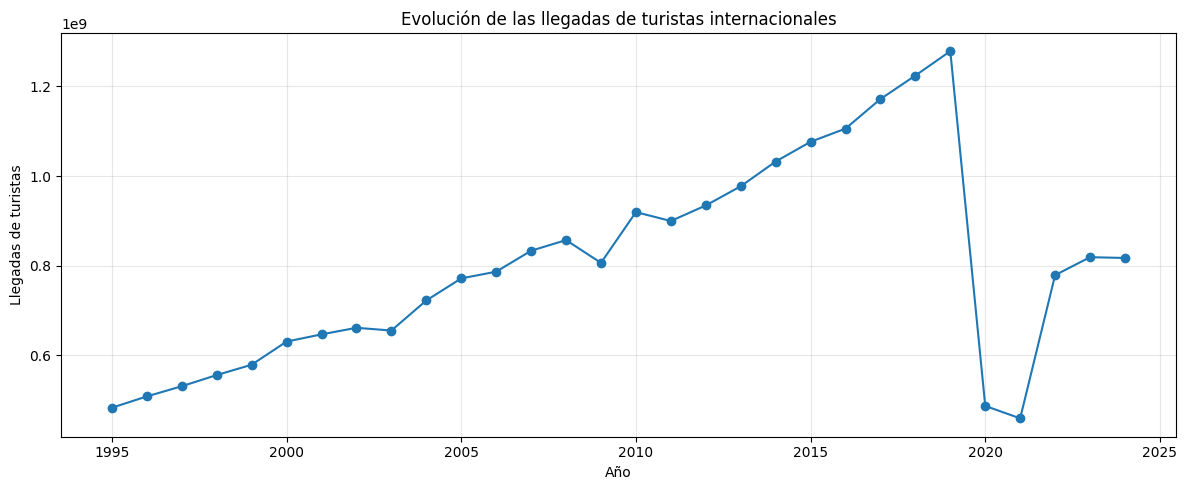

In [36]:
# ============================================================
# GRÁFICO - EVOLUCIÓN DEL TURISMO INTERNACIONAL
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    tourism_year['year'],
    tourism_year['tourist_arrivals'],
    marker='o'
)

plt.title('Evolución de las llegadas de turistas internacionales')
plt.xlabel('Año')
plt.ylabel('Llegadas de turistas')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.1.1. Interpretación

La evolución de las llegadas de turistas internacionales muestra una tendencia general creciente entre 1995 y 2019.

A partir de 2020 se observa una caída muy pronunciada, seguida de una recuperación durante los años posteriores. En 2024 el volumen de llegadas vuelve a situarse en niveles elevados, aunque todavía por debajo del máximo observado antes de la caída.

La evolución temporal muestra, por tanto, un crecimiento del turismo internacional a largo plazo y una alteración excepcional del comportamiento durante el periodo 2020-2021.

## 6.2. Países con mayor volumen de llegadas turísticas

Se identifican los países que registran el mayor número de llegadas de turistas internacionales en el último año disponible en el dataset Tourism.

Este análisis permite comparar los principales destinos turísticos y conocer cómo se distribuye el volumen de llegadas entre los países.

In [37]:
# ============================================================
# TOP 10 PAÍSES POR LLEGADAS TURÍSTICAS
# ============================================================

ultimo_año = tourism['year'].max()

top_10_turismo = (
    tourism[tourism['year'] == ultimo_año]
    .sort_values('tourist_arrivals', ascending=False)
    .head(10)
    [['country_name', 'tourist_arrivals']]
)

print(f"Último año disponible: {ultimo_año}")
top_10_turismo

Último año disponible: 2024


,country_name,tourist_arrivals
4516,Spain,93759300
5069,United States,72390320
2335,Italy,57725000
3032,Mexico,45038750
5039,United Kingdom,38229570
1851,Germany,37420000
2368,Japan,36870000
1554,El Salvador,31869885
4222,Saudi Arabia,29727444
3908,Portugal,28970000


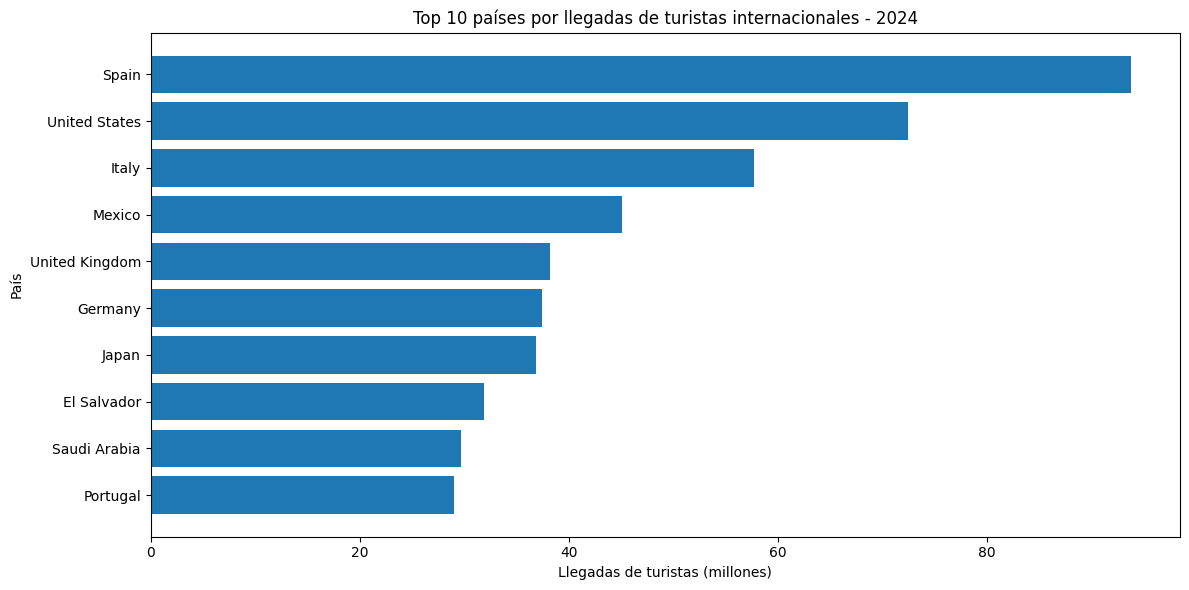

In [39]:
# ============================================================
# GRÁFICO - TOP 10 PAÍSES POR LLEGADAS TURÍSTICAS
# ============================================================

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_turismo['country_name'][::-1],
    top_10_turismo['tourist_arrivals'][::-1] / 1_000_000
)

plt.title('Top 10 países por llegadas de turistas internacionales - 2024')
plt.xlabel('Llegadas de turistas (millones)')
plt.ylabel('País')

plt.tight_layout()
plt.show()

### 6.2.1. Interpretación

En 2024, España registra el mayor volumen de llegadas de turistas internacionales dentro del conjunto de países analizado, con aproximadamente 93,8 millones de llegadas. Le siguen Estados Unidos, con 72,4 millones, e Italia, con 57,7 millones.

El análisis muestra una concentración importante del turismo internacional entre los principales destinos. España presenta una diferencia significativa respecto al resto de países del Top 10, mientras que entre los siguientes puestos las diferencias son más reducidas.

Los resultados permiten identificar los principales destinos turísticos del dataset y proporcionan una primera referencia para analizar posteriormente la relación entre volumen turístico y factores económicos, demográficos y sociales.

## 6.3. Evolución del PIB per cápita

Se analiza la evolución del PIB per cápita a lo largo del periodo disponible en el dataset GDP per Capita.

Este análisis permite observar la evolución del nivel económico medio de los países y establecer una primera referencia para estudiar posteriormente su posible relación con el comportamiento turístico.

In [44]:
# ============================================================
# EVOLUCIÓN DEL PIB PER CÁPITA
# ============================================================

gdp_numeric = (
    gdp
    .drop(columns=['country_name', 'country_code'])
    .replace(',', '.', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

gdp_year = gdp_numeric.mean().reset_index()

gdp_year.columns = ['year', 'gdp_per_capita']

gdp_year['year'] = gdp_year['year'].astype(int)

gdp_year

,year,gdp_per_capita
0,1960,471.908954
1,1961,491.272288
2,1962,538.786441
3,1963,571.710262
4,1964,617.878933
...,...,...
61,2021,18902.963319
62,2022,19598.113850
63,2023,20577.839714
64,2024,20709.148422


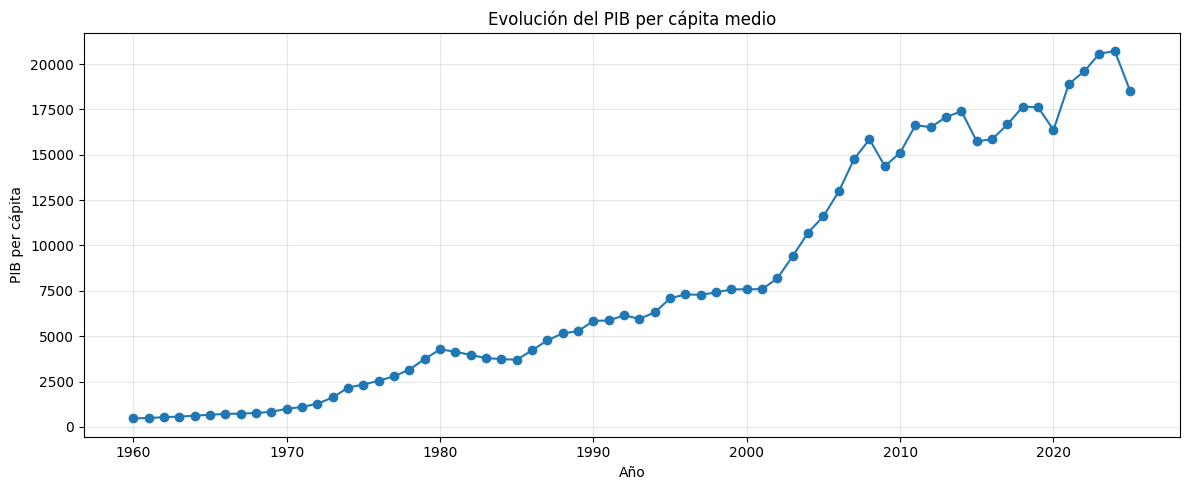

In [45]:
# ============================================================
# GRÁFICO - EVOLUCIÓN DEL PIB PER CÁPITA
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    gdp_year['year'],
    gdp_year['gdp_per_capita'],
    marker='o'
)

plt.title('Evolución del PIB per cápita medio')
plt.xlabel('Año')
plt.ylabel('PIB per cápita')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3.1. Interpretación

La evolución del PIB per cápita medio muestra una tendencia general creciente a lo largo del periodo analizado.

Entre las décadas de 1960 y 1990 se observa un crecimiento progresivo, aunque con algunos periodos de estabilización y descenso. A partir de comienzos de los años 2000 el crecimiento se acelera, alcanzando valores superiores a 15.000 en la década de 2010.

En los últimos años se mantienen niveles elevados, aunque se observan algunas fluctuaciones. El valor máximo del periodo se alcanza en torno a 2023-2024, seguido de un descenso en 2025.

Esta evolución proporciona una referencia para analizar posteriormente la posible relación entre el nivel económico de los países y el comportamiento del turismo internacional.

## 6.4. Evolución de la población

Se analiza la evolución de la población media de los países a lo largo del periodo disponible en el dataset Population.

Este análisis permite observar la evolución demográfica del conjunto de países analizado y establecer una referencia para estudiar posteriormente su posible relación con el turismo internacional.

In [46]:
# ============================================================
# EVOLUCIÓN DE LA POBLACIÓN
# ============================================================

population_numeric = (
    population
    .drop(columns=['country_name', 'country_code'])
    .replace(',', '.', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

population_year = population_numeric.mean().reset_index()

population_year.columns = ['year', 'population']

population_year['year'] = population_year['year'].astype(int)

population_year

,year,population
0,1960,1.153120e+08
1,1961,1.169136e+08
2,1962,1.190730e+08
3,1963,1.217435e+08
4,1964,1.244376e+08
...,...,...
61,2021,3.211230e+08
62,2022,3.242488e+08
63,2023,3.275260e+08
64,2024,3.309670e+08


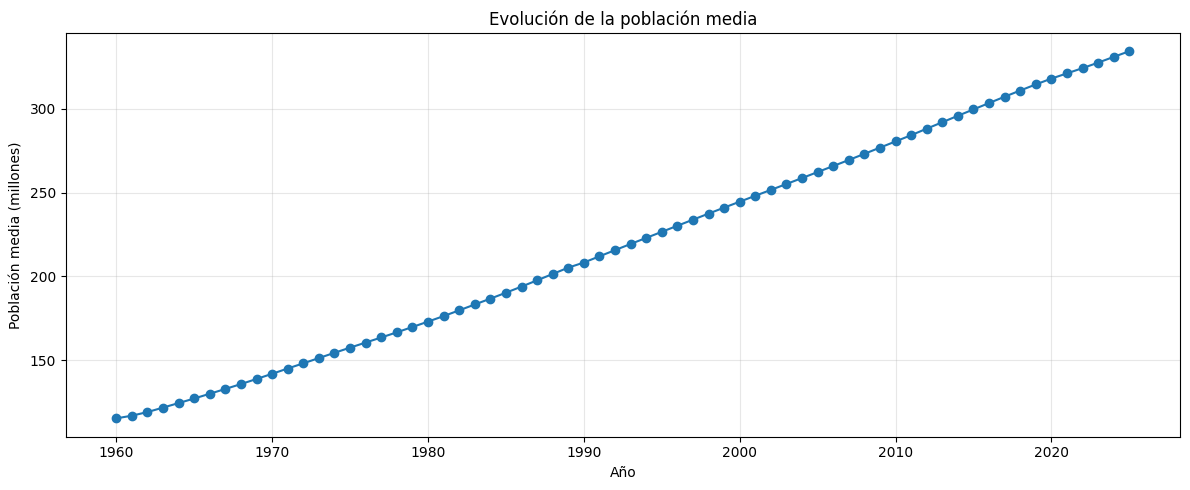

In [47]:
# ============================================================
# GRÁFICO - EVOLUCIÓN DE LA POBLACIÓN
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    population_year['year'],
    population_year['population'] / 1_000_000,
    marker='o'
)

plt.title('Evolución de la población media')
plt.xlabel('Año')
plt.ylabel('Población media (millones)')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4.1. Interpretación

La evolución de la población media muestra un crecimiento continuo a lo largo de todo el periodo analizado.

En 1960 la población media de los países incluidos en el dataset se sitúa en torno a 115 millones de habitantes, mientras que en 2025 supera los 330 millones.

La tendencia es progresiva y no presenta descensos significativos, mostrando un incremento sostenido de la población a lo largo del periodo.

Este comportamiento proporciona una referencia demográfica que permitirá analizar posteriormente su posible relación con la evolución del turismo internacional.

## 6.5. Indicadores de felicidad

Se analiza el comportamiento de los principales indicadores relacionados con la felicidad y el bienestar de los países a lo largo del periodo disponible en el dataset World Happiness.

Este análisis permite observar las diferencias y tendencias de los indicadores de felicidad y establecer una referencia para estudiar posteriormente su posible relación con factores económicos, sociales y turísticos.

In [48]:
# ============================================================
# INDICADORES DE FELICIDAD
# ============================================================

happiness_numeric = happiness.copy()

happiness_numeric['life_evaluation'] = (
    happiness_numeric['life_evaluation']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

happiness_numeric['life_evaluation'] = pd.to_numeric(
    happiness_numeric['life_evaluation'],
    errors='coerce'
)

happiness_year = (
    happiness_numeric
    .groupby('year', as_index=False)['life_evaluation']
    .mean()
)

happiness_year

,year,life_evaluation
0,2011,5.391538
1,2012,5.418731
2,2014,5.375741
3,2015,5.382185
4,2016,5.354019
5,2017,5.375878
6,2018,5.407096
7,2019,5.473240
8,2020,5.532839
9,2021,5.553575


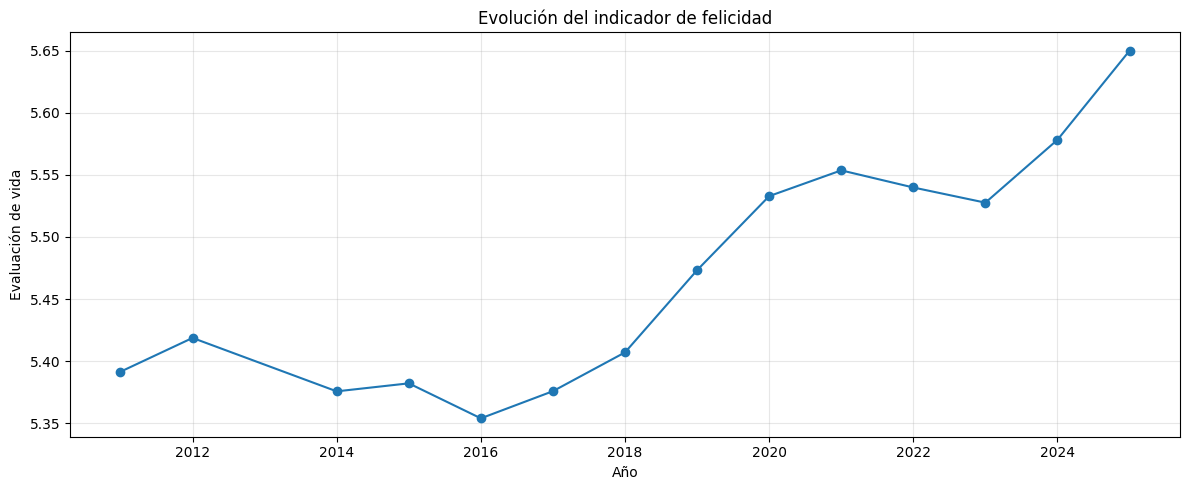

In [49]:
# ============================================================
# GRÁFICO - INDICADOR DE FELICIDAD
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    happiness_year['year'],
    happiness_year['life_evaluation'],
    marker='o'
)

plt.title('Evolución del indicador de felicidad')
plt.xlabel('Año')
plt.ylabel('Evaluación de vida')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.5.1. Interpretación

La evaluación de vida media presenta algunas fluctuaciones durante los primeros años del periodo analizado, alcanzando su valor más bajo en 2016.

A partir de 2017 se observa una tendencia general creciente, especialmente entre 2018 y 2021. Posteriormente se produce un ligero descenso entre 2021 y 2023, seguido de una nueva recuperación en 2024 y 2025.

En 2025 se alcanza el valor más elevado del periodo, con una evaluación de vida media de aproximadamente 5,65.

Este comportamiento permite utilizar el indicador de felicidad como una referencia para estudiar posteriormente su posible relación con factores económicos y turísticos.

## 6.6. Evolución del Global Peace Index

Se analiza la evolución de la puntuación media del Global Peace Index de los países a lo largo de los años disponibles en el dataset.

Este análisis permite observar el comportamiento general del indicador de paz y establecer una referencia para estudiar posteriormente su posible relación con el turismo internacional.

In [50]:
# ============================================================
# EVOLUCIÓN DEL GLOBAL PEACE INDEX
# ============================================================

peace_scores = peace[
    [col for col in peace.columns if col.endswith('_Score')]
].copy()

peace_scores = (
    peace_scores
    .replace(',', '.', regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

peace_year = peace_scores.mean().reset_index()

peace_year.columns = ['year', 'peace_score']

peace_year['year'] = (
    peace_year['year']
    .str.replace('_Score', '', regex=False)
    .astype(int)
)

peace_year

,year,peace_score
0,2008,1.942602
1,2009,1.967671
2,2010,1.968373
3,2011,1.953261
4,2012,1.965698
5,2013,1.954759
6,2014,1.951802
7,2015,1.988173
8,2016,2.003669
9,2017,2.021080


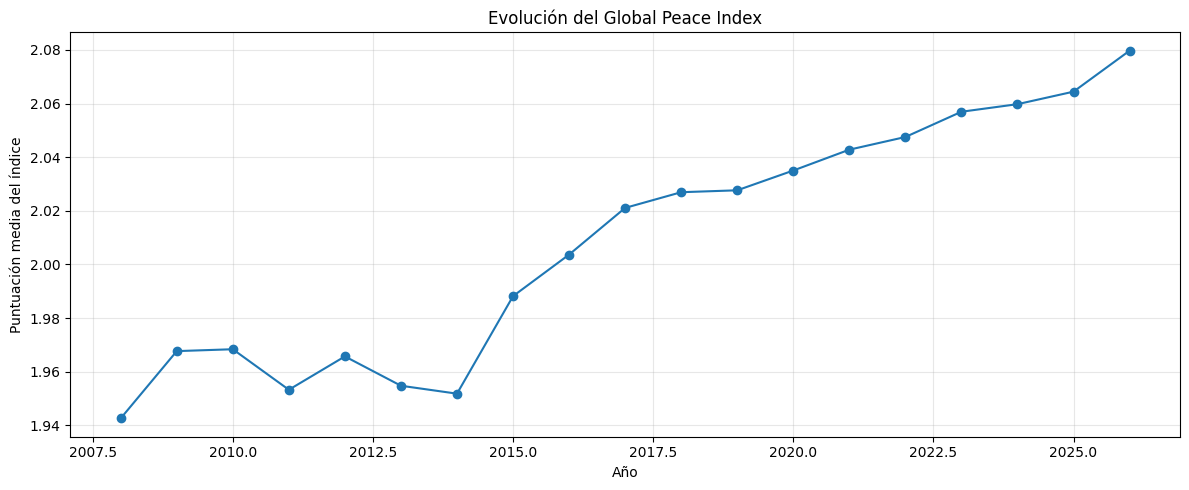

In [51]:
# ============================================================
# GRÁFICO - EVOLUCIÓN DEL GLOBAL PEACE INDEX
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    peace_year['year'],
    peace_year['peace_score'],
    marker='o'
)

plt.title('Evolución del Global Peace Index')
plt.xlabel('Año')
plt.ylabel('Puntuación media del índice')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.6.1. Interpretación

La puntuación media del Global Peace Index muestra una tendencia general creciente durante el periodo analizado.

El indicador pasa de aproximadamente 1,94 en 2008 a valores cercanos a 2,08 en los últimos años. Aunque se observan pequeñas fluctuaciones durante los primeros años, a partir de 2015 se aprecia un incremento más continuado de la puntuación.

Dado que en el Global Peace Index una puntuación más baja representa un mayor nivel de paz, esta evolución indica un ligero deterioro del nivel medio de paz de los países incluidos en el dataset.

Este indicador permitirá analizar posteriormente la posible relación entre el nivel de paz de los países y su comportamiento turístico.

## 6.7. Distribución de sitios de patrimonio UNESCO

Se analiza la distribución de los sitios de patrimonio mundial incluidos en el dataset UNESCO según su año de inscripción.

Este análisis permite observar cómo ha evolucionado la incorporación de nuevos sitios al patrimonio mundial a lo largo del tiempo.

In [52]:
# ============================================================
# DISTRIBUCIÓN DE SITIOS UNESCO POR AÑO DE INSCRIPCIÓN
# ============================================================

unesco_year = (
    unesco
    .groupby('inscription_year')
    .size()
    .reset_index(name='number_of_sites')
    .sort_values('inscription_year')
)

unesco_year

,inscription_year,number_of_sites
0,1978,12
1,1979,45
2,1980,27
3,1981,26
4,1982,24
5,1983,29
6,1984,22
7,1985,30
8,1986,29
9,1987,41


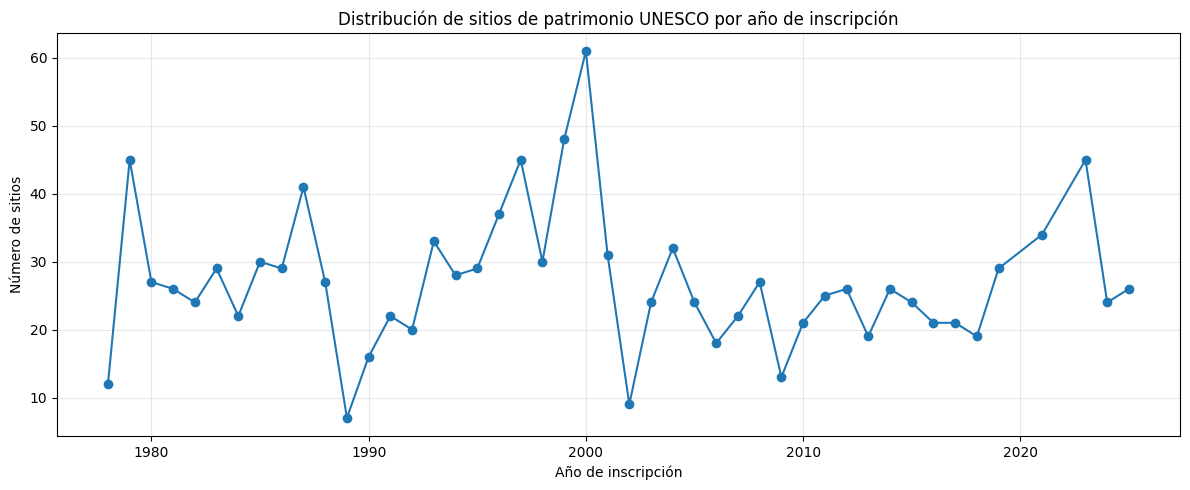

In [53]:
# ============================================================
# GRÁFICO - DISTRIBUCIÓN DE SITIOS UNESCO
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    unesco_year['inscription_year'],
    unesco_year['number_of_sites'],
    marker='o'
)

plt.title('Distribución de sitios de patrimonio UNESCO por año de inscripción')
plt.xlabel('Año de inscripción')
plt.ylabel('Número de sitios')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.7.1. Interpretación

La distribución de los sitios de patrimonio mundial presenta importantes variaciones entre los diferentes años de inscripción.

Se observan varios periodos con un número elevado de nuevas inscripciones, destacando especialmente el año 2000, con más de 60 sitios incorporados. También se registran valores elevados durante algunos años de las décadas de 1970, 1980 y 1990.

En otros años el número de nuevas inscripciones es considerablemente menor, mostrando que la incorporación de sitios al patrimonio mundial no sigue una evolución constante.

Este análisis permite conocer la distribución temporal de las inscripciones UNESCO y proporciona una referencia para estudiar posteriormente la relación entre patrimonio cultural, turismo y otros factores del proyecto.

## 6.8. Relación entre turismo y factores económicos y sociales

Se analiza la relación entre las llegadas de turistas internacionales y diferentes factores económicos y sociales de los países.

Para ello, se integran los datos disponibles para 2024 de Tourism, GDP per Capita y World Happiness, utilizando el país como elemento común.

Este análisis permite explorar si existen diferencias en el volumen turístico de los países en función de su nivel económico y de su evaluación de vida.

In [54]:
# ============================================================
# RELACIÓN ENTRE TURISMO, PIB Y FELICIDAD - 2024
# ============================================================

# GDP per cápita de 2024
gdp_2024 = gdp[['country_name', '2024']].copy()

gdp_2024['2024'] = (
    gdp_2024['2024']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

gdp_2024['2024'] = pd.to_numeric(
    gdp_2024['2024'],
    errors='coerce'
)

gdp_2024 = gdp_2024.rename(
    columns={'2024': 'gdp_per_capita'}
)

# Turismo 2024
tourism_2024 = tourism[
    tourism['year'] == 2024
][['country_name', 'tourist_arrivals']].copy()

# Happiness 2024
happiness_2024 = happiness[
    happiness['year'] == 2024
][['country_name', 'life_evaluation']].copy()

happiness_2024['life_evaluation'] = (
    happiness_2024['life_evaluation']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

happiness_2024['life_evaluation'] = pd.to_numeric(
    happiness_2024['life_evaluation'],
    errors='coerce'
)

# Unión de los tres datasets
tourism_economic_social = (
    tourism_2024
    .merge(gdp_2024, on='country_name', how='inner')
    .merge(happiness_2024, on='country_name', how='inner')
)

tourism_economic_social.head()

,country_name,tourist_arrivals,gdp_per_capita,life_evaluation
0,Albania,11483000,11374.00858,5.411
1,Argentina,6603877,13969.78366,6.397
2,Armenia,2208000,8556.21407,5.494
3,Bahrain,6618000,29717.14246,6.030
4,Belgium,9638000,56581.93756,6.910


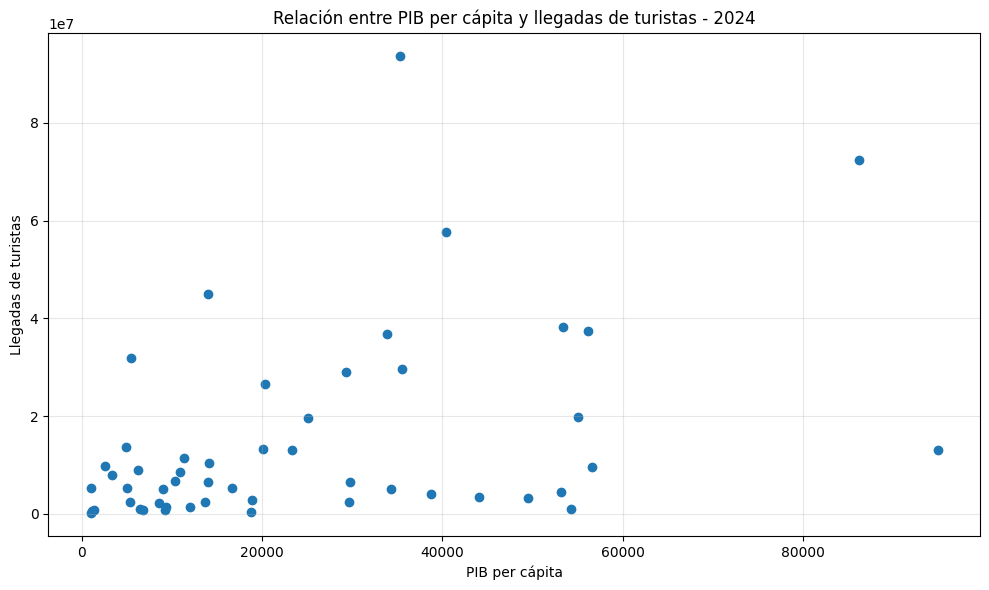

In [55]:
# ============================================================
# GRÁFICO - TURISMO VS PIB PER CÁPITA
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    tourism_economic_social['gdp_per_capita'],
    tourism_economic_social['tourist_arrivals']
)

plt.title('Relación entre PIB per cápita y llegadas de turistas - 2024')
plt.xlabel('PIB per cápita')
plt.ylabel('Llegadas de turistas')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.8.1. Interpretación

La distribución de los datos no muestra una relación lineal clara entre el PIB per cápita y las llegadas de turistas internacionales en 2024.

Se observan países con niveles elevados de PIB per cápita que presentan un volumen turístico muy diferente entre sí. Del mismo modo, algunos países con un PIB per cápita moderado registran un número elevado de llegadas.

El gráfico muestra también la presencia de algunos valores extremos con un volumen de llegadas considerablemente superior al de la mayoría de los países analizados.

Por tanto, el nivel económico por sí solo no parece explicar el volumen de turismo internacional. Este resultado indica que existen otros factores que pueden influir en las llegadas turísticas y que deberán analizarse conjuntamente.

## 6.9. Principales relaciones entre variables

Se analiza la relación entre las principales variables económicas, sociales y turísticas disponibles para los países.

Para ello, se utilizan los datos de 2024 de llegadas de turistas, PIB per cápita, evaluación de vida y puntuación del Global Peace Index.

La matriz de correlación permite identificar la intensidad y dirección de las relaciones lineales entre estas variables.

In [56]:
# ============================================================
# PRINCIPALES RELACIONES ENTRE VARIABLES - 2024
# ============================================================

# Global Peace Index 2024
peace_2024 = peace[['country_name', '2024_Score']].copy()

peace_2024['2024_Score'] = (
    peace_2024['2024_Score']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

peace_2024['2024_Score'] = pd.to_numeric(
    peace_2024['2024_Score'],
    errors='coerce'
)

peace_2024 = peace_2024.rename(
    columns={'2024_Score': 'peace_score'}
)

# Unión con el dataset anterior
correlation_data = tourism_economic_social.merge(
    peace_2024,
    on='country_name',
    how='inner'
)

# Selección de variables para el análisis
correlation_data = correlation_data[
    [
        'tourist_arrivals',
        'gdp_per_capita',
        'life_evaluation',
        'peace_score'
    ]
]

correlation_data.head()

,tourist_arrivals,gdp_per_capita,life_evaluation,peace_score
0,11483000,11374.00858,5.411,1.720
1,6603877,13969.78366,6.397,1.875
2,2208000,8556.21407,5.494,1.945
3,6618000,29717.14246,6.030,2.050
4,9638000,56581.93756,6.910,1.551


In [57]:
# ============================================================
# MATRIZ DE CORRELACIÓN - 2024
# ============================================================

correlation_matrix = correlation_data.corr()

correlation_matrix

,tourist_arrivals,gdp_per_capita,life_evaluation,peace_score
tourist_arrivals,1.000000,0.304112,0.275533,-0.196896
gdp_per_capita,0.304112,1.000000,0.632957,-0.461073
life_evaluation,0.275533,0.632957,1.000000,-0.507128
peace_score,-0.196896,-0.461073,-0.507128,1.000000


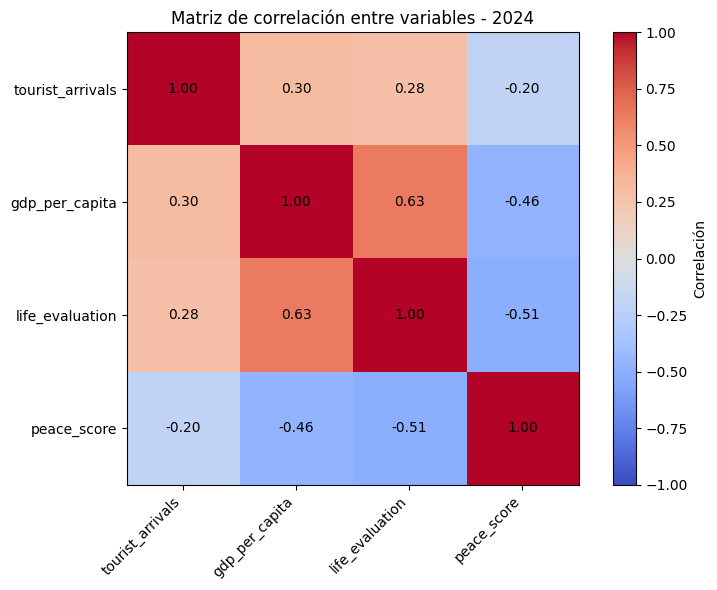

In [58]:
# ============================================================
# GRÁFICO - MATRIZ DE CORRELACIÓN
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Correlación')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j,
            i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Matriz de correlación entre variables - 2024')

plt.tight_layout()
plt.show()

### 6.9.1. Interpretación

La matriz de correlación muestra diferentes relaciones entre las variables analizadas en 2024.

Las llegadas de turistas presentan una correlación positiva moderada-baja con el PIB per cápita (0,30) y con la evaluación de vida (0,28). Esto indica que, en el conjunto de países analizado, los países con mayores niveles de estas variables tienden a presentar también un mayor volumen de llegadas, aunque la relación no es especialmente fuerte.

La relación entre PIB per cápita y evaluación de vida es más elevada, con una correlación de 0,63, mostrando una asociación positiva considerable entre ambas variables.

La puntuación del Global Peace Index presenta una correlación negativa con las llegadas de turistas (-0,20), el PIB per cápita (-0,46) y la evaluación de vida (-0,51). En este indicador debe tenerse en cuenta que una puntuación más baja representa un mayor nivel de paz.

En conjunto, los resultados muestran que el volumen turístico no depende de una única variable, sino que puede estar relacionado con diferentes factores económicos y sociales. Las correlaciones permiten identificar estas asociaciones, aunque no implican necesariamente una relación causal entre las variables.

# 7. CONCLUSIONES Y PRINCIPALES HALLAZGOS

## 7.1. Principales resultados del análisis

El análisis realizado permite identificar diferentes patrones relevantes en el comportamiento turístico internacional y su relación con factores económicos, demográficos y sociales.

En primer lugar, las llegadas de turistas internacionales presentan una tendencia general creciente a lo largo del periodo analizado, con una caída excepcional a partir de 2020 y una posterior recuperación. En 2024, España registra el mayor volumen de llegadas dentro del conjunto de países analizado.

Desde el punto de vista económico, el PIB per cápita muestra una evolución general creciente a lo largo del periodo estudiado. Sin embargo, el análisis realizado para 2024 no muestra una relación lineal fuerte entre el PIB per cápita y el volumen de llegadas turísticas.

La población media de los países analizados presenta un crecimiento continuo durante todo el periodo disponible, pasando de aproximadamente 115 millones de habitantes en 1960 a más de 330 millones en 2025.

En relación con la felicidad, la evaluación de vida presenta fluctuaciones durante los primeros años y una tendencia general creciente en los últimos años del periodo analizado, alcanzando su valor máximo en 2025.

El Global Peace Index muestra un incremento de su puntuación media a lo largo del periodo. Dado que una puntuación más baja representa un mayor nivel de paz, los resultados indican un deterioro moderado del nivel medio de paz de los países incluidos en el análisis.

Por último, la distribución de las inscripciones de sitios UNESCO presenta importantes variaciones entre años, sin una tendencia creciente constante.

En conjunto, los resultados muestran que el comportamiento turístico internacional está relacionado con diferentes factores económicos, sociales, demográficos y patrimoniales, por lo que su análisis requiere considerar múltiples variables conjuntamente.

## 7.2. Principales relaciones identificadas

El análisis de correlación realizado sobre los datos de 2024 permite identificar diferentes relaciones entre las variables turísticas, económicas y sociales.

La relación entre las llegadas de turistas y el PIB per cápita presenta una correlación positiva de 0,30. La relación entre las llegadas de turistas y la evaluación de vida alcanza un valor de 0,28, por lo que ambas asociaciones son positivas, aunque de intensidad moderada-baja.

La relación más elevada entre las variables analizadas se observa entre el PIB per cápita y la evaluación de vida, con una correlación de 0,63.

Por otro lado, la puntuación del Global Peace Index presenta correlaciones negativas con las llegadas de turistas (-0,20), el PIB per cápita (-0,46) y la evaluación de vida (-0,51). En este caso, debe tenerse en cuenta que una puntuación menor del Global Peace Index representa un mayor nivel de paz.

Estos resultados muestran que existen asociaciones entre las diferentes dimensiones analizadas, aunque las correlaciones no permiten establecer relaciones de causalidad.

## 7.3. Conclusión general

El análisis realizado sobre los diferentes datasets permite obtener una visión conjunta de los principales factores relacionados con el turismo internacional.

Los resultados muestran una evolución creciente del turismo a largo plazo, acompañada por cambios relevantes en variables económicas, demográficas y sociales. Sin embargo, el análisis de 2024 indica que ninguna de estas variables, considerada de forma aislada, explica por completo las diferencias observadas en el volumen de llegadas turísticas entre países.

Las relaciones identificadas mediante el análisis de correlación muestran asociaciones de diferente intensidad entre turismo, PIB per cápita, evaluación de vida y nivel de paz. Estos resultados ponen de manifiesto la necesidad de analizar el fenómeno turístico desde una perspectiva multidimensional.

En conjunto, el proyecto proporciona una base de datos integrada y un análisis exploratorio que permite comprender mejor la relación entre turismo y diferentes factores económicos, sociales, demográficos y patrimoniales, y que servirá como base para las siguientes fases del proyecto.